In [ ]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 



df = pd.read_csv(r"Telco_customer.csv")
df.shape

(7043, 33)

In [2]:
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [2]:
df['Churn Value'].value_counts()

Churn Value
0    5174
1    1869
Name: count, dtype: int64

In [2]:
df = df.drop_duplicates()

In [5]:
df.isnull().sum()

CustomerID              0
Count                   0
Country                 0
State                   0
City                    0
Zip Code                0
Lat Long                0
Latitude                0
Longitude               0
Gender                  0
Senior Citizen          0
Partner                 0
Dependents              0
Tenure Months           0
Phone Service           0
Multiple Lines          0
Internet Service        0
Online Security         0
Online Backup           0
Device Protection       0
Tech Support            0
Streaming TV            0
Streaming Movies        0
Contract                0
Paperless Billing       0
Payment Method          0
Monthly Charges         0
Total Charges           0
Churn Label             0
Churn Value             0
Churn Score             0
CLTV                    0
Churn Reason         5174
dtype: int64

In [3]:
df.drop(columns=['Churn Reason' , 'Churn Label' , 'Count' , 'Lat Long' , 'CustomerID' , 'Zip Code' , 'Country', 'State', 'City', 'Latitude', 'Longitude' , 'Churn Score' , 'CLTV'] , inplace=True)


<Axes: xlabel='Gender', ylabel='Churn Value'>

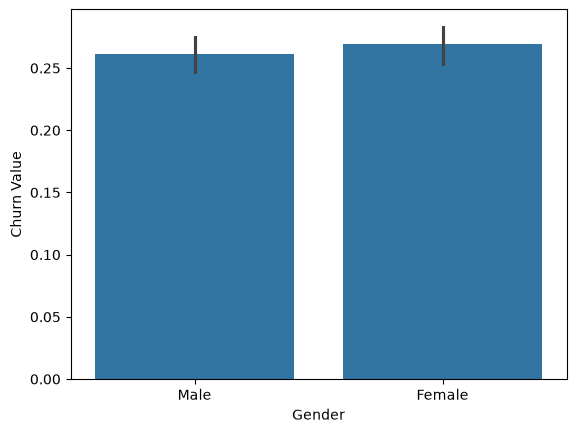

In [5]:

sns.barplot(x=df.Gender , y=df['Churn Value'])

<Axes: xlabel='Gender', ylabel='Total Charges'>

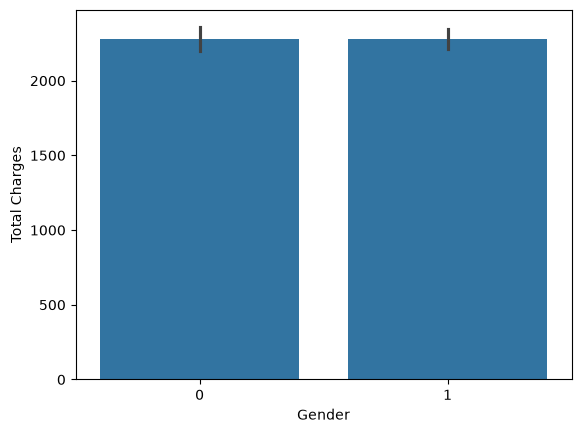

In [28]:

sns.barplot(x=df.Gender , y=df['Total Charges'])

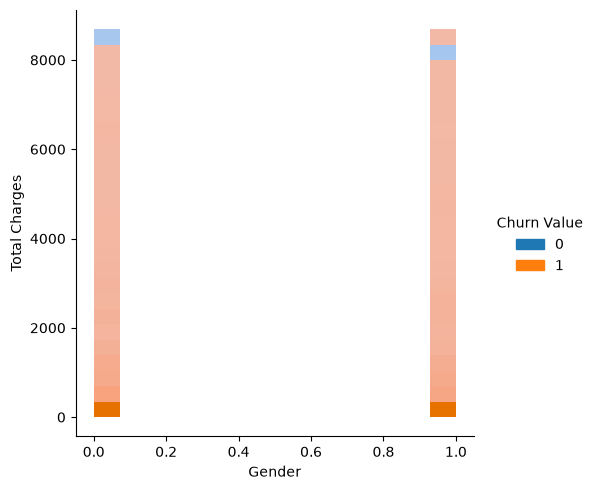

In [34]:
sns.displot(x=df.Gender , y=df['Total Charges'], hue=df['Churn Value'])

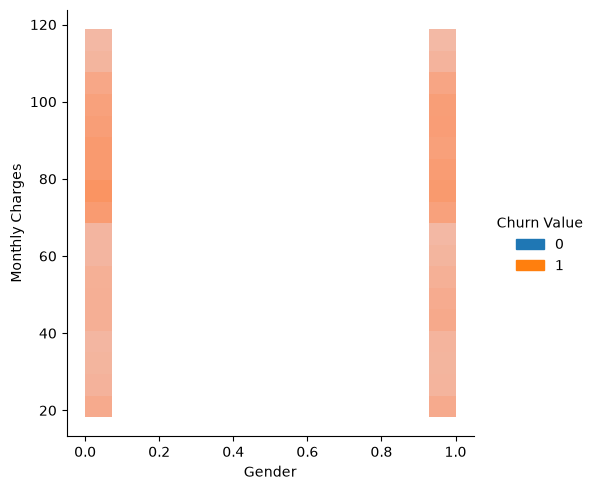

In [33]:
sns.displot(x=df.Gender , y=df['Monthly Charges'] , hue=df['Churn Value'])

<Axes: xlabel='Monthly Charges', ylabel='Total Charges'>

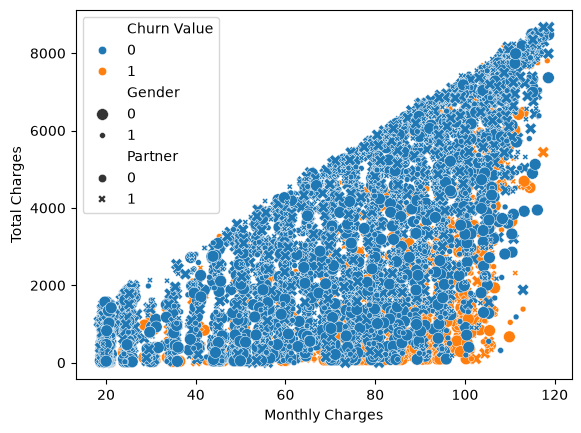

In [31]:
sns.scatterplot(x=df['Monthly Charges'] , y=df['Total Charges'] , hue=df['Churn Value'] , size=df.Gender , style=df.Partner)

<Axes: xlabel='Gender', ylabel='count'>

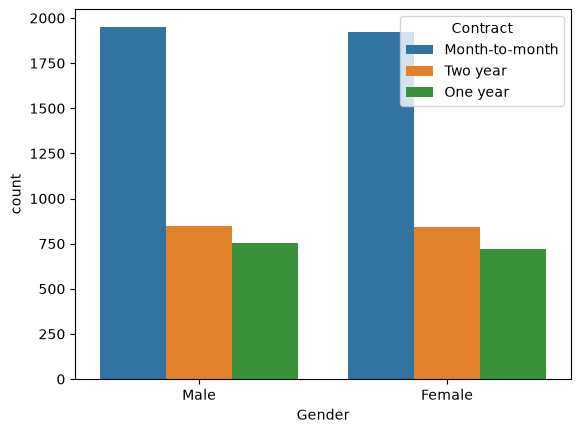

In [41]:
sns.countplot(x=df['Gender'] , hue=df['Contract'])

<Axes: xlabel='Gender', ylabel='count'>

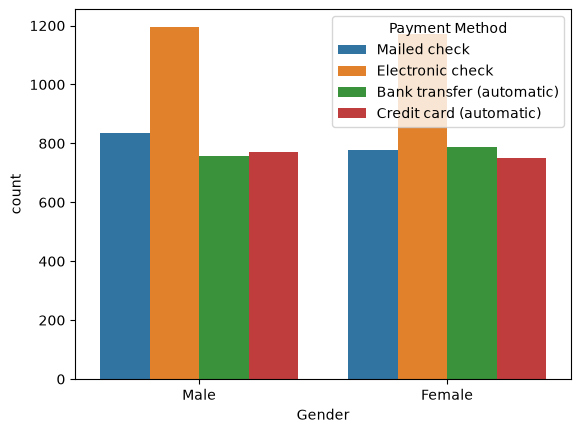

In [40]:
sns.countplot(x=df['Gender'] , hue=df['Payment Method'])

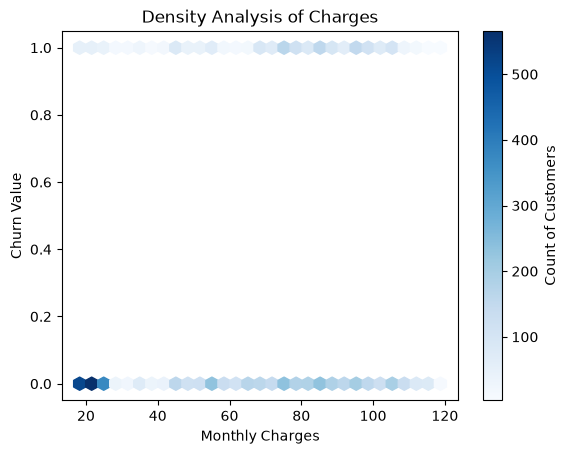

In [37]:
# This treats the chart like a population heatmap
plt.hexbin(data=df, x='Monthly Charges', y='Churn Value', gridsize=30, cmap='Blues', mincnt=1)

plt.colorbar(label='Count of Customers')
plt.xlabel('Monthly Charges')
plt.ylabel('Churn Value')
plt.title('Density Analysis of Charges')
plt.show()


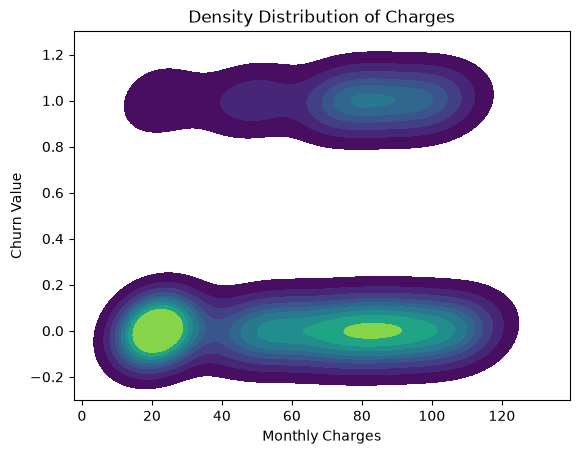

In [33]:
# fill=True creates smooth color transitions for high-density areas
sns.kdeplot(data=df, x='Monthly Charges', y='Churn Value', fill=True, cmap='viridis', thresh=0.05)

plt.title('Density Distribution of Charges')
plt.show()


In [4]:
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')

# 2. Fill those new NaN values with 0 (since new customers have 0 charges)
df['Total Charges'] = df['Total Charges'].fillna(0)

# 3. Check the data type to make sure it is now a float
print(df['Total Charges'].dtype)

float64


In [ ]:
df['Total Charges'].isnull().sum()

np.int64(0)

In [5]:
df['Gender'] = df['Gender'].map({'Male': 1 , 'Female': 0})
df['Senior Citizen'] = df['Senior Citizen'].map({'Yes': 1 , 'No': 0})
df['Partner'] = df['Partner'].map({'Yes': 1 , 'No': 0})
df['Dependents'] = df['Dependents'].map({'Yes': 1 , 'No': 0})
df['Phone Service'] = df['Phone Service'].map({'Yes': 1 , 'No': 0})
df['Paperless Billing'] = df['Paperless Billing'].map({'Yes': 1 , 'No': 0})

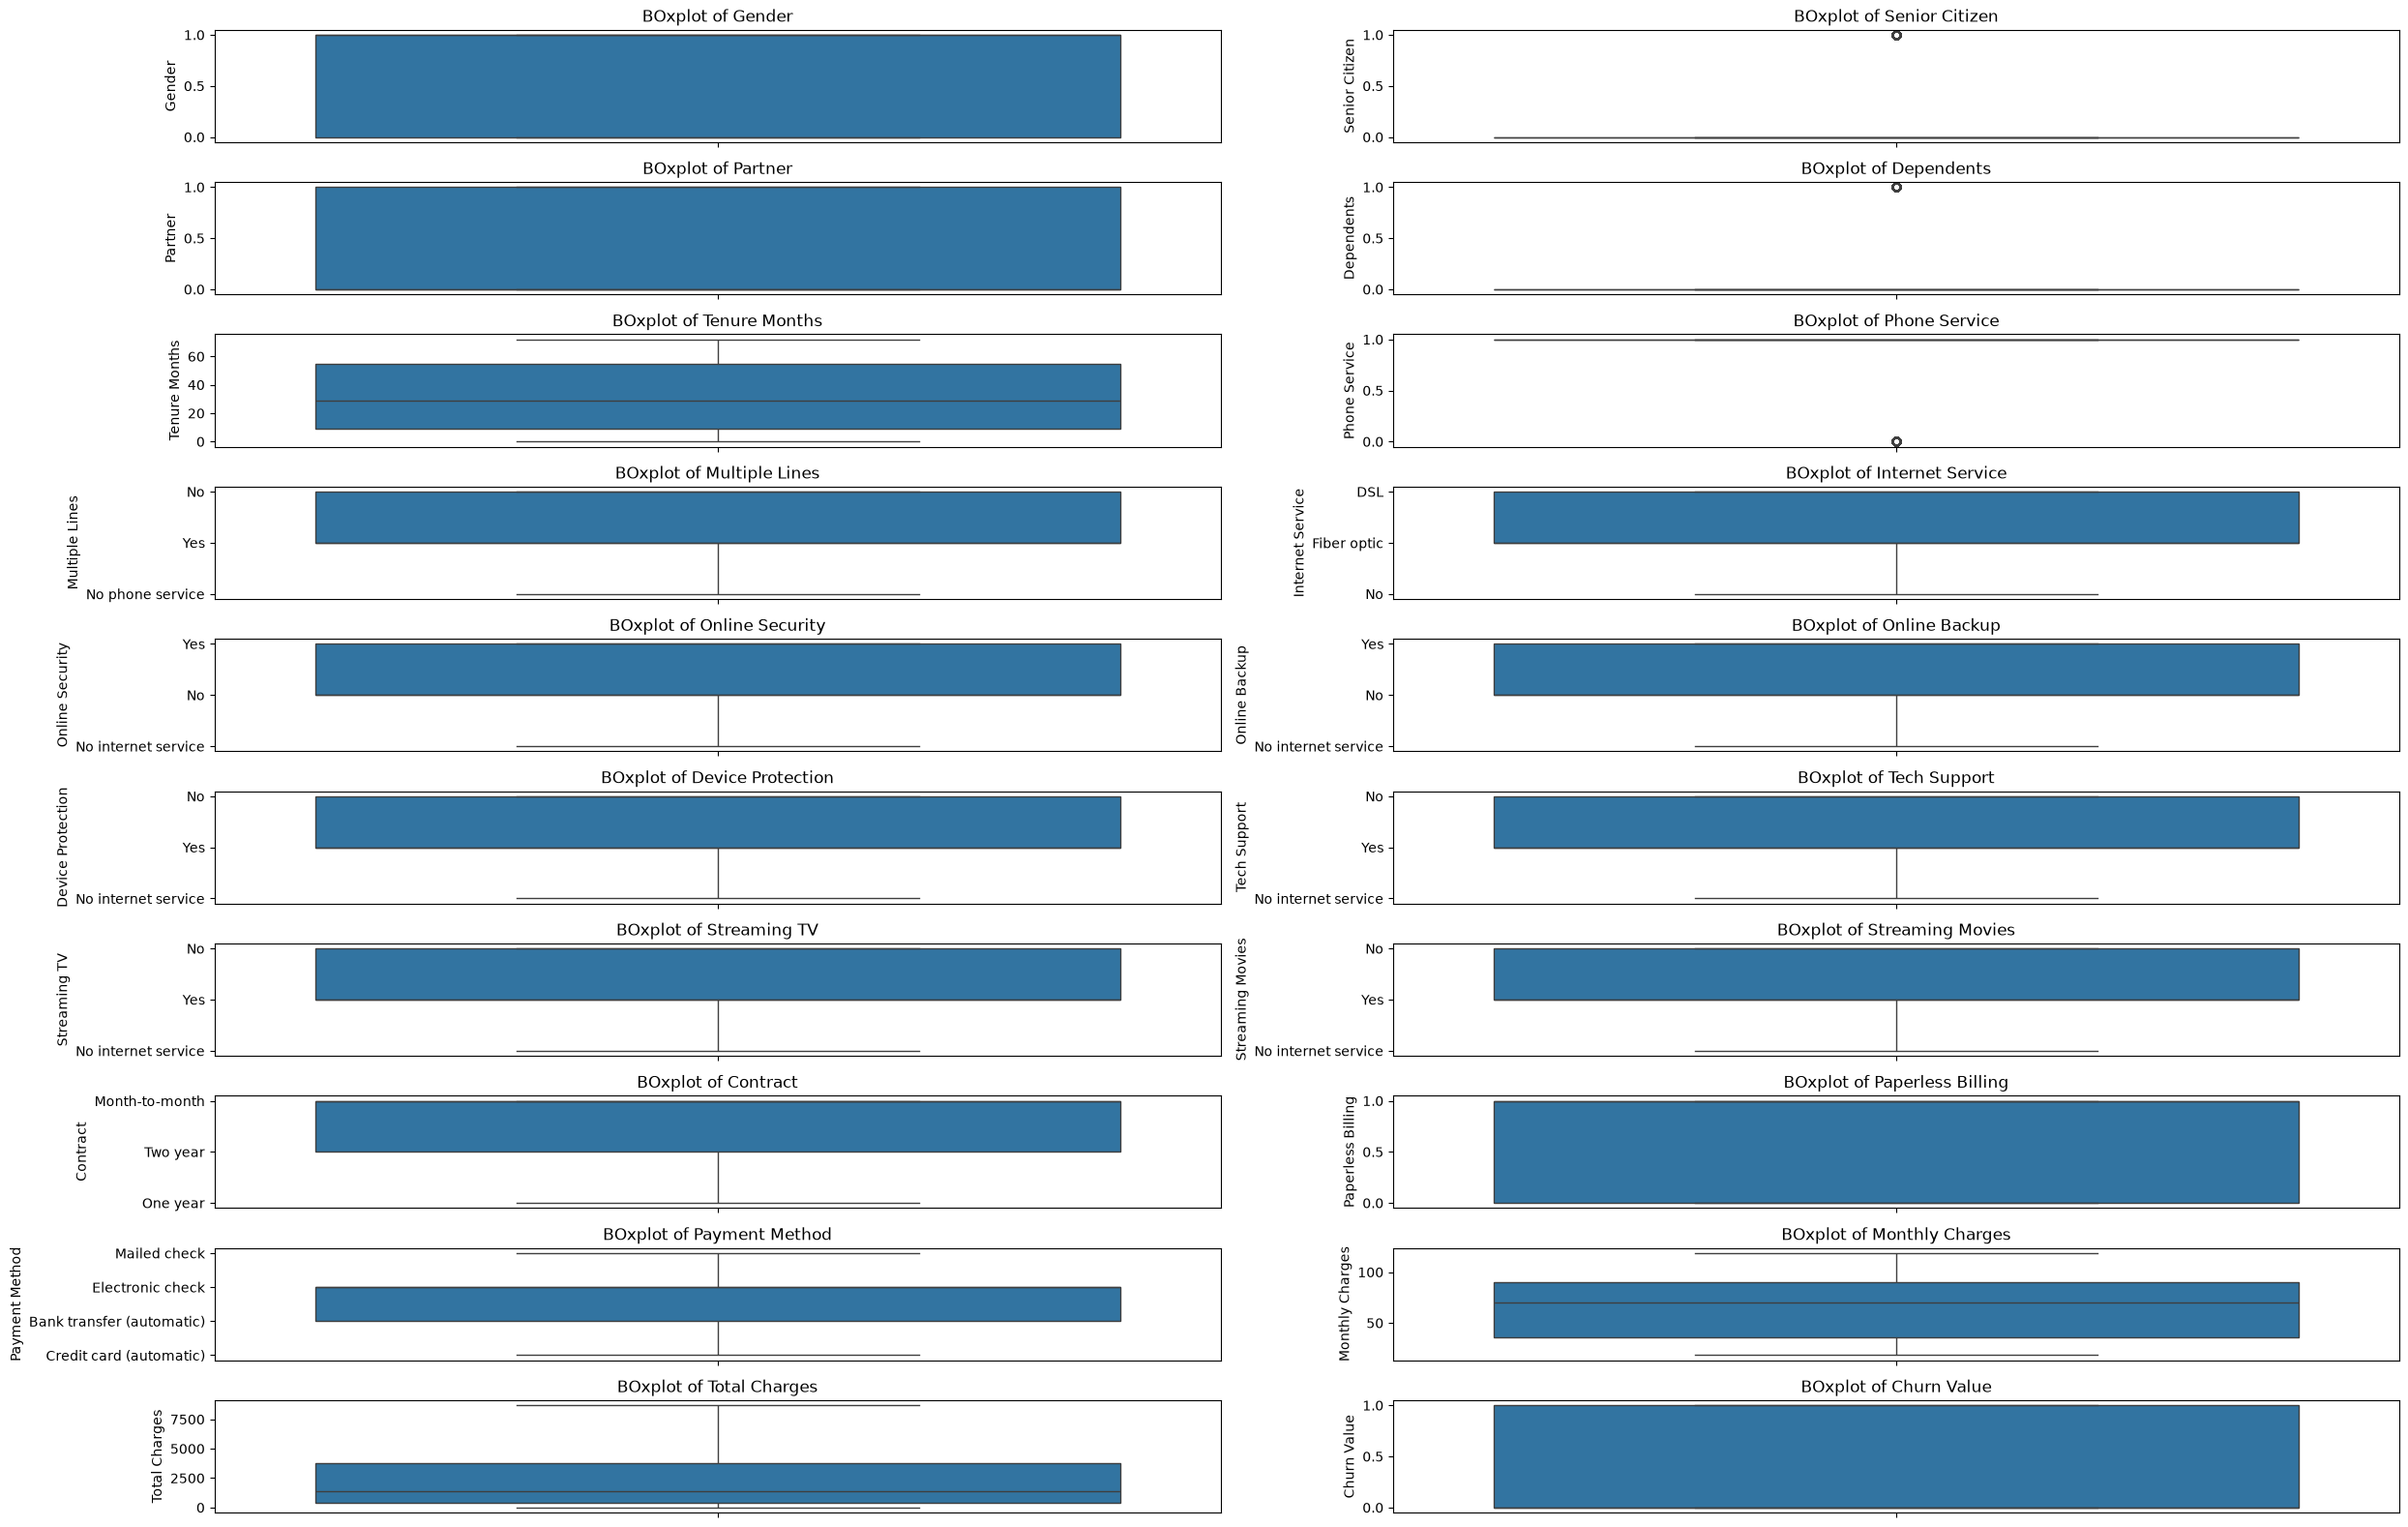

In [14]:
plt.figure(figsize=(25 , 30))
plot_index = 1
for col in df.columns:
    if plot_index > 38:
        break
    plt.subplot(19 , 2 , plot_index)
    sns.boxplot(df[col])
    plt.title(f"BOxplot of {col}")
    plot_index += 1
plt.tight_layout()
plt.show()

C:\Users\ah266\AppData\Local\Temp\ipykernel_25544\3375858509.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[col])
C:\Users\ah266\AppData\Local\Temp\ipykernel_25544\3375858509.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[col])
C:\Users\ah266\AppData\Local\Temp\ipykernel_25544\33

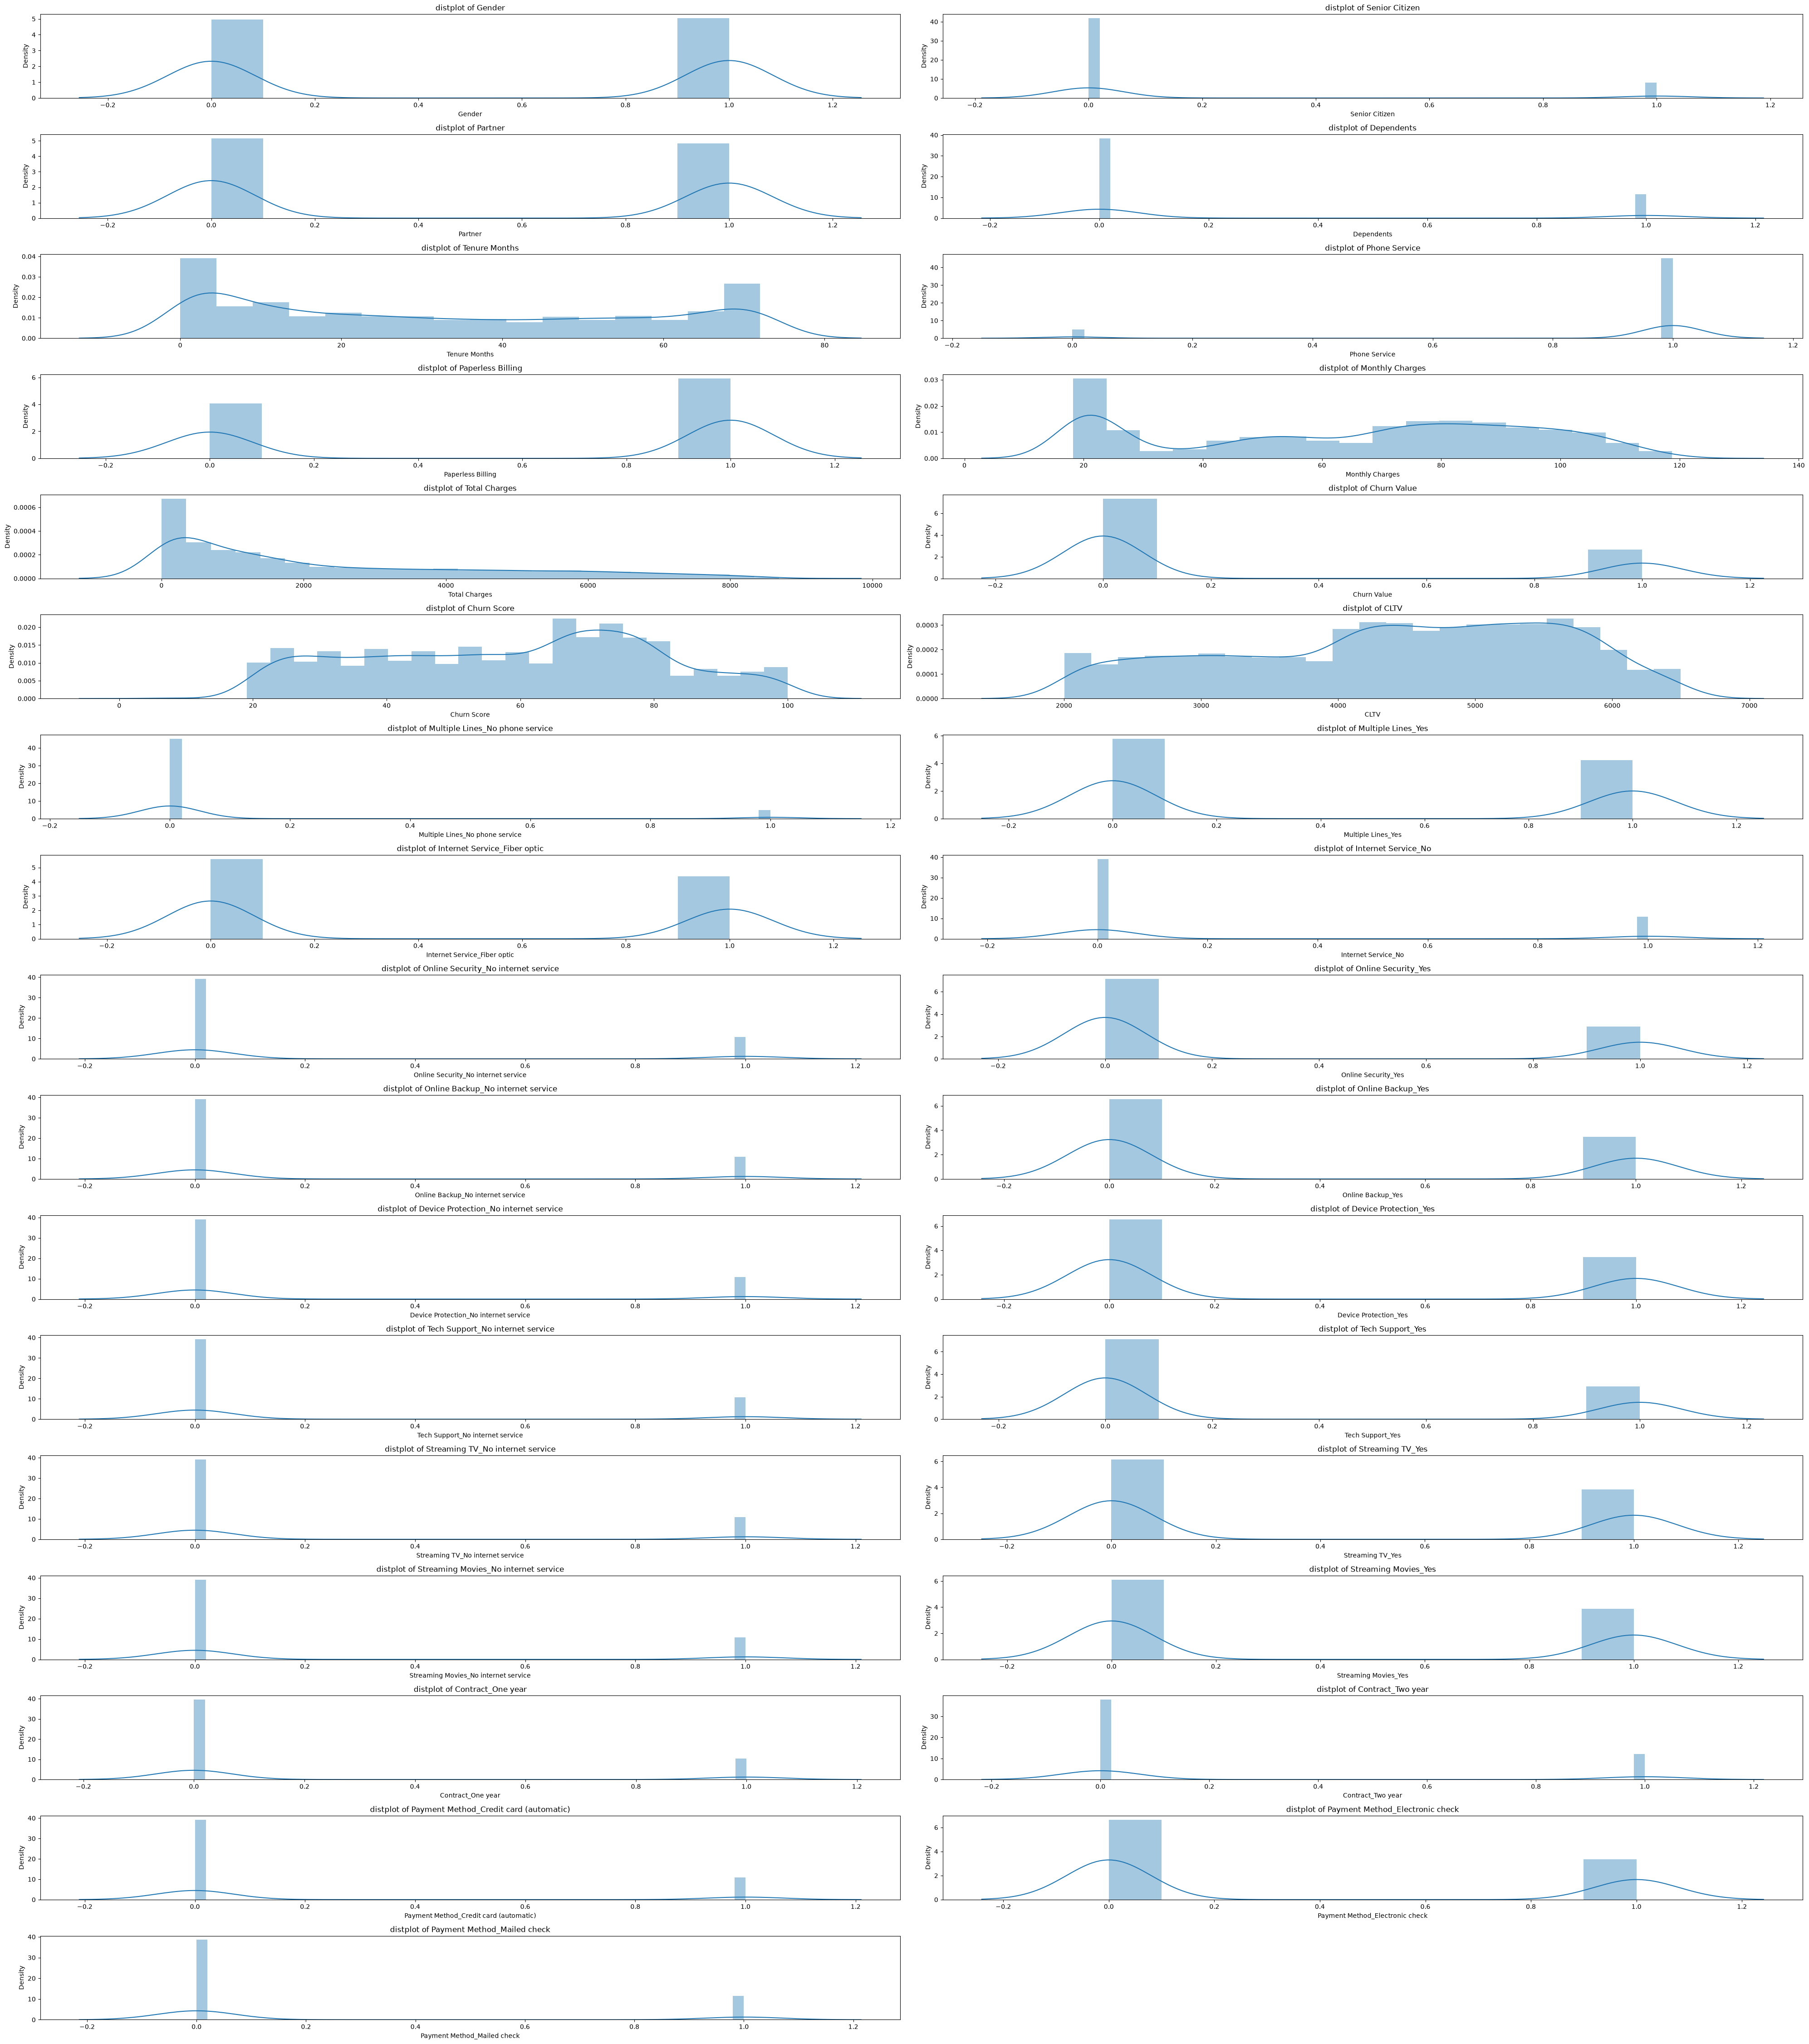

In [23]:
plt.figure(figsize=(40 , 50))
plot_index = 1
for col in df.columns:
    if plot_index > 38:
        break
    plt.subplot(19 , 2 , plot_index)
    sns.distplot(df[col])
    plt.title(f"distplot of {col}")
    plot_index += 1
plt.tight_layout()
plt.show()

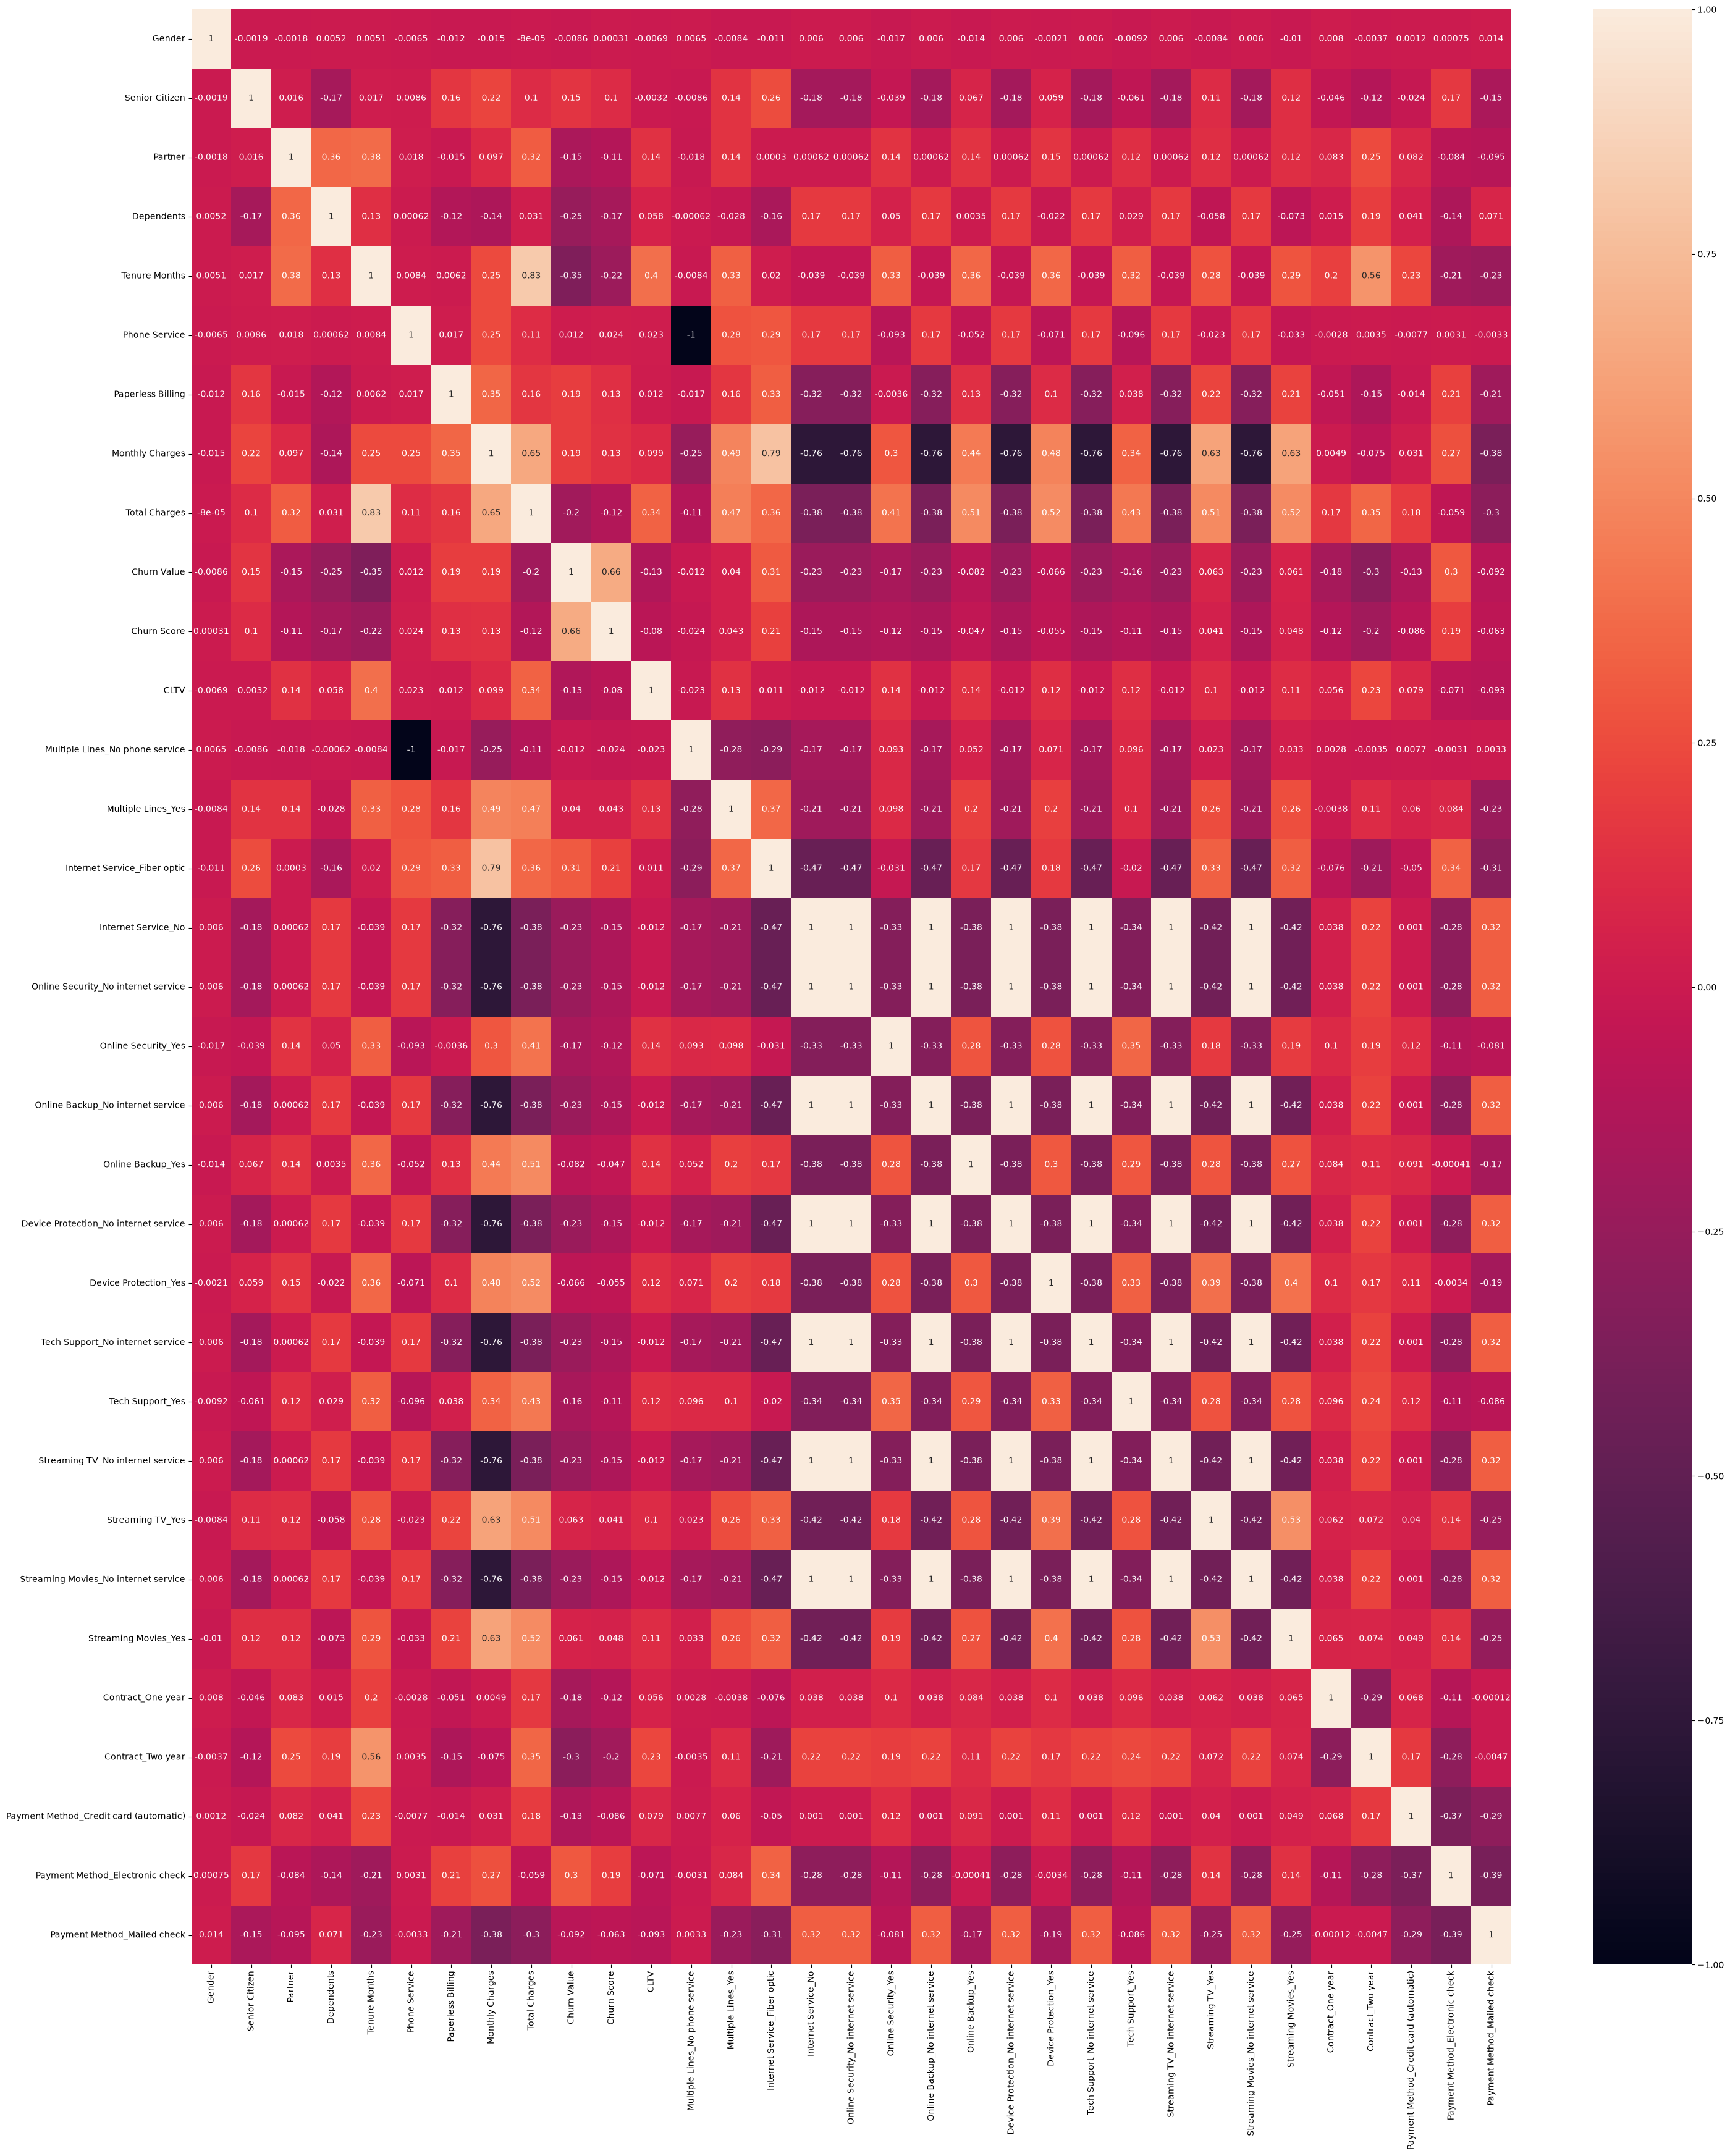

In [42]:
plt.figure(figsize=(30 , 35))
sns.heatmap(df.corr() , annot=True)
plt.tight_layout()
plt.show()

In [6]:
from sklearn.preprocessing import StandardScaler , OneHotEncoder

from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split , cross_val_score
from sklearn.metrics import accuracy_score , confusion_matrix , classification_report , ConfusionMatrixDisplay , RocCurveDisplay , PrecisionRecallDisplay , roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier , GradientBoostingClassifier 
from xgboost import XGBClassifier
from catboost import CatBoostClassifier 
from lightgbm import LGBMClassifier 
from imblearn.over_sampling import SMOTE 
from imblearn.pipeline import Pipeline



In [7]:
x = df.drop(columns=['Churn Value'])
y = df['Churn Value']


In [8]:
X_train , X_test , y_train , y_test = train_test_split(x , y , test_size=0.2 , random_state=42 , stratify=y)

In [9]:
categorical = ['Multiple Lines' , 'Internet Service' , 'Online Security' , 'Online Backup' , 'Device Protection' , 'Tech Support' , 'Streaming TV' , 'Streaming Movies' , 'Contract' , 'Payment Method']
num_cols = ['Monthly Charges' , 'Total Charges' , 'Tenure Months']
preprocessor = ColumnTransformer(
    transformers=[
    ("onehot" , OneHotEncoder(drop='first') , categorical) ,
    ("standard" , StandardScaler() , num_cols)
] , remainder='passthrough')

In [28]:
y_test.value_counts()

Churn Value
0    1035
1     374
Name: count, dtype: int64

In [45]:
pipeline = Pipeline([
    ("preprocessor" , preprocessor) ,
    ("cat" , CatBoostClassifier(verbose=0 , class_weights=[1 , 5] , max_depth=5 , n_estimators=300 , learning_rate=0.3))
])

In [10]:
pipeline = Pipeline([
    ("preprocessor" , preprocessor) ,
    ("smote" , SMOTE(sampling_strategy=0.6 , random_state=42)) ,
    ("cat" , CatBoostClassifier(verbose=0 , random_state=42 , max_depth=5 , learning_rate=0.03 , n_estimators=300))
])

In [11]:
pipeline.fit(X_train , y_train)
pred = pipeline.predict(X_test)
acc = accuracy_score(y_test , pred)
clr = classification_report(y_test , pred)
roc = roc_auc_score(y_test , pipeline.predict_proba(X_test)[: , 1])
cv = cross_val_score(
    pipeline ,
    X_train ,
    y_train ,
    cv = 5 ,
    scoring='f1'
).mean()
print("accu" , acc)
print(clr)
print("roc" , roc)
print("cv" , cv)

accu 0.801277501774308
              precision    recall  f1-score   support

           0       0.87      0.86      0.86      1035
           1       0.62      0.63      0.63       374

    accuracy                           0.80      1409
   macro avg       0.75      0.75      0.75      1409
weighted avg       0.80      0.80      0.80      1409

roc 0.85766230075693
cv 0.6423523136850852


In [12]:
pred = pipeline.predict(X_train)
acc = accuracy_score(y_train , pred)
print(acc)

0.824103656372027


In [80]:
pipeline1 = Pipeline([
    ("preprocessor" , preprocessor) ,
    ("smote" , SMOTE(sampling_strategy=0.6 , random_state=42)) ,
    ("cat" , LogisticRegression(max_iter=200))
])
pipeline1.fit(X_train , y_train)
pred = pipeline1.predict(X_test)
acc = accuracy_score(y_test , pred)
clr = classification_report(y_test , pred)
roc = roc_auc_score(y_test , pipeline1.predict_proba(X_test)[: , 1])
cv = cross_val_score(
    pipeline1 ,
    X_train ,
    y_train ,
    cv = 5 ,
    scoring='f1'
).mean()
print("accu" ,acc)
print(clr)
print("roc" , roc)
print("cv" , cv)

accu 0.7806955287437899
              precision    recall  f1-score   support

           0       0.88      0.81      0.84      1035
           1       0.57      0.70      0.63       374

    accuracy                           0.78      1409
   macro avg       0.73      0.75      0.74      1409
weighted avg       0.80      0.78      0.79      1409

roc 0.8487716035030612
cv 0.6477872012342215


In [55]:
pred = pipeline1.predict(X_train)
acc = accuracy_score(y_train , pred)
print(acc)

0.7976570820021299


In [84]:
pipeline2 = Pipeline([
    ("preprocessor" , preprocessor) ,
    ("smote" , SMOTE(sampling_strategy=0.6 , random_state=42)) ,
    ("xgb" , XGBClassifier(random_state=42 , max_depth=5 , n_estimators=300 , learning_rate=0.04))
])
pipeline2.fit(X_train , y_train)
pred = pipeline2.predict(X_test)
acc = accuracy_score(y_test , pred)
clr = classification_report(y_test , pred)
roc = roc_auc_score(y_test , pipeline2.predict_proba(X_test)[: , 1])
cv = cross_val_score(
    pipeline2 ,
    X_train ,
    y_train ,
    cv = 5 ,
    scoring='f1'
).mean()
print("accu" ,acc)
print(clr)
print("roc" , roc)
print("cv" , cv)

accu 0.7877927608232789
              precision    recall  f1-score   support

           0       0.86      0.85      0.85      1035
           1       0.60      0.62      0.61       374

    accuracy                           0.79      1409
   macro avg       0.73      0.73      0.73      1409
weighted avg       0.79      0.79      0.79      1409

roc 0.8507478880880415
cv 0.6297063866877133


In [72]:
pred = pipeline2.predict(X_train)
acc = accuracy_score(y_train , pred)
print(acc)

0.8487752928647497


In [ ]:
import joblib
joblib.dump(pipeline , r"models\v1\model_v1.pkl")

['C:\\Users\\ah266\\OneDrive\\Documents\\production-ml-reliability\\models\\v1\\model_v1.pkl']

In [17]:
X_train.columns.to_list()

['Gender',
 'Senior Citizen',
 'Partner',
 'Dependents',
 'Tenure Months',
 'Phone Service',
 'Multiple Lines',
 'Internet Service',
 'Online Security',
 'Online Backup',
 'Device Protection',
 'Tech Support',
 'Streaming TV',
 'Streaming Movies',
 'Contract',
 'Paperless Billing',
 'Payment Method',
 'Monthly Charges',
 'Total Charges']